In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import json
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from omegaconf import OmegaConf
from tqdm.auto import tqdm

from model import GraphTrajectoryLM
from tokenizer_utils import load_tokenizer

# ── Configuration ────────────────────────────────────────────────────────────
CHECKPOINT_PATH = "checkpoints/epoch-epoch=01-val_loss-val/loss=1.7344.ckpt"
TOKENIZER_DIR = "data_output_large_critical_rw_directed_2/tokenizer"
GRAPH_PATH = "data_output_large_critical_rw_directed_2/graph.json"
CONFIG_PATH = "conf/config.yaml"

M = 50             # number of (u, v) pairs per distance
NUM_ATTEMPTS = 5   # attempts per pair
TEMPERATURE = 0.8
TOP_K = 20
MAX_NEW_TOKENS = 80
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED)
torch.manual_seed(SEED)

In [9]:
# ── Load tokenizer, model, graph ─────────────────────────────────────────────
tokenizer = load_tokenizer(TOKENIZER_DIR)
cfg = OmegaConf.load(CONFIG_PATH)

model = GraphTrajectoryLM(
    vocab_size=tokenizer.vocab_size,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
    model_config=cfg.model,
    train_config=cfg.train,
)
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["state_dict"])
del ckpt
model.eval()
model.to(DEVICE)
print(f"Model loaded on {DEVICE}  |  vocab size: {tokenizer.vocab_size}")

with open(GRAPH_PATH) as f:
    graph_data = json.load(f)

directed = graph_data.get("directed", False)
G = nx.DiGraph() if directed else nx.Graph()
for node, neighbors in graph_data["adjacency"].items():
    for nb in neighbors:
        G.add_edge(int(node), int(nb))

kind = "directed" if directed else "undirected"
component = "weakly connected" if directed else "connected"
print(f"Graph ({kind}, {component} component): "
      f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Training max path length: {cfg.data.max_path_length}")
if directed:
    dead_ends = [n for n in G.nodes() if G.out_degree(n) == 0]
    print(f"Dead-end nodes (no outgoing edges): {len(dead_ends)}")

Model loaded on cuda  |  vocab size: 7944
Graph (directed, weakly connected component): 7939 nodes, 9559 edges
Training max path length: 10
Dead-end nodes (no outgoing edges): 2018


In [11]:
# ── Build distance-indexed pair buckets ──────────────────────────────────────
# For large graphs, computing all-pairs shortest paths is expensive.
# Instead, sample source nodes and bucket their reachable targets by distance.
# For directed graphs with weakly connected components, not every (u, v) pair
# is reachable via directed edges.  We only evaluate reachable pairs.

nodes = list(G.nodes())
pairs_by_dist: dict[int, list[tuple[int, int]]] = defaultdict(list)

SAMPLE_SOURCES = min(500, len(nodes))
source_sample = random.sample(nodes, SAMPLE_SOURCES)

total_reachable = 0
total_possible = SAMPLE_SOURCES * (len(nodes) - 1)

for src in tqdm(source_sample, desc="Computing shortest paths from sampled sources"):
    lengths = nx.single_source_shortest_path_length(G, src)
    for tgt, d in lengths.items():
        if tgt != src:
            pairs_by_dist[d].append((src, tgt))
            total_reachable += 1

max_dist = max(pairs_by_dist.keys())
print(f"Max distance found: {max_dist}")
print(f"Training max path length: {cfg.data.max_path_length}")

if directed:
    reachability_pct = total_reachable / total_possible * 100 if total_possible else 0
    print(f"\nDirected graph reachability: {total_reachable:,}/{total_possible:,} "
          f"sampled pairs are reachable ({reachability_pct:.1f}%)")

print(f"\nPairs available per distance:")
for d in sorted(pairs_by_dist.keys()):
    print(f"  d={d:>2d}: {len(pairs_by_dist[d]):>7,} pairs")

Computing shortest paths from sampled sources: 100%|██████████| 500/500 [00:00<00:00, 24974.12it/s]

Max distance found: 87
Training max path length: 10

Directed graph reachability: 43,587/3,969,000 sampled pairs are reachable (1.1%)

Pairs available per distance:
  d= 1:     604 pairs
  d= 2:     606 pairs
  d= 3:     621 pairs
  d= 4:     596 pairs
  d= 5:     635 pairs
  d= 6:     699 pairs
  d= 7:     713 pairs
  d= 8:     739 pairs
  d= 9:     777 pairs
  d=10:     815 pairs
  d=11:     833 pairs
  d=12:     841 pairs
  d=13:     860 pairs
  d=14:     866 pairs
  d=15:     913 pairs
  d=16:     903 pairs
  d=17:     923 pairs
  d=18:     930 pairs
  d=19:     910 pairs
  d=20:     901 pairs
  d=21:     958 pairs
  d=22:     945 pairs
  d=23:     945 pairs
  d=24:     943 pairs
  d=25:     932 pairs
  d=26:     963 pairs
  d=27:     927 pairs
  d=28:     959 pairs
  d=29:     944 pairs
  d=30:     961 pairs
  d=31:     919 pairs
  d=32:     895 pairs
  d=33:     858 pairs
  d=34:     837 pairs
  d=35:     770 pairs
  d=36:     740 pairs
  d=37:     724 pairs
  d=38:     725 pairs

In [12]:
# ── Inference helpers ─────────────────────────────────────────────────────────

@torch.no_grad()
def generate_trajectory(start_node: int, goal_node: int) -> list[str]:
    """Autoregressively sample a trajectory. Returns the generated path tokens."""
    prompt = f"<start_goal> {start_node} {goal_node} <end_goal>"
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

    eos_id = tokenizer.eos_token_id
    pad_id = tokenizer.pad_token_id

    generated = input_ids
    for _ in range(MAX_NEW_TOKENS):
        logits = model.model(input_ids=generated).logits[:, -1, :] / TEMPERATURE
        logits[:, pad_id] = -float("inf")

        if TOP_K > 0:
            topk_vals, _ = torch.topk(logits, TOP_K)
            logits[logits < topk_vals[:, -1:]] = -float("inf")

        next_token = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
        generated = torch.cat([generated, next_token], dim=-1)
        if next_token.item() == eos_id:
            break

    path_tokens = tokenizer.decode(generated[0, input_ids.shape[1]:], skip_special_tokens=True).split()
    return path_tokens


def is_valid_and_reaches_goal(start: int, goal: int, path_tokens: list[str]) -> bool:
    """True iff the path is a valid walk in G from start that ends at goal."""
    try:
        path_nodes = [int(t) for t in path_tokens if t != "<eos>"]
    except ValueError:
        return False
    if not path_nodes or path_nodes[0] != start or path_nodes[-1] != goal:
        return False
    return all(G.has_edge(path_nodes[i], path_nodes[i + 1]) for i in range(len(path_nodes) - 1))

In [13]:
# ── Run evaluation ────────────────────────────────────────────────────────────
results: dict[int, dict] = {}  # dist -> {successes, total}

for dist in tqdm(sorted(pairs_by_dist.keys()), desc="Evaluating distances"):
    pool = pairs_by_dist[dist]
    selected = random.sample(pool, min(M, len(pool)))
    successes = 0

    for u, v in tqdm(selected, desc=f"  d={dist}", leave=False):
        solved = False
        for _ in range(NUM_ATTEMPTS):
            path_tokens = generate_trajectory(u, v)
            if is_valid_and_reaches_goal(u, v, path_tokens):
                solved = True
                break
        if solved:
            successes += 1

    results[dist] = {"successes": successes, "total": len(selected)}
    acc = successes / len(selected) * 100
    print(f"  d={dist:>2d}:  {successes}/{len(selected)}  ({acc:.1f}%)")

Evaluating distances:   1%|          | 1/87 [00:03<05:08,  3.59s/it]

  d= 1:  48/50  (96.0%)


Evaluating distances:   2%|▏         | 2/87 [00:11<08:16,  5.85s/it]

  d= 2:  40/50  (80.0%)


Evaluating distances:   3%|▎         | 3/87 [00:22<11:36,  8.29s/it]

...

  d=16:  1/50  (2.0%)


Evaluating distances:  20%|█▉        | 17/87 [06:30<36:52, 31.60s/it]

  d=17:  0/50  (0.0%)


Evaluating distances:  20%|█▉        | 17/87 [06:37<27:18, 23.41s/it]


KeyboardInterrupt: 

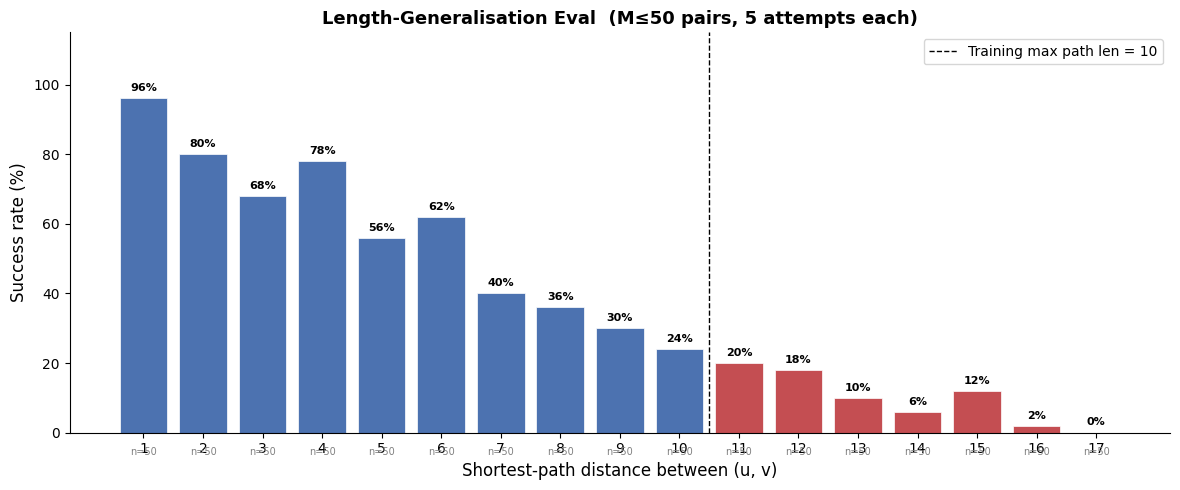


Saved plot to length_generalization_eval.png


In [14]:
# ── Plot ──────────────────────────────────────────────────────────────────────
train_max = cfg.data.max_path_length

distances = sorted(results.keys())
accuracies = [results[d]["successes"] / results[d]["total"] * 100 for d in distances]
counts = [results[d]["total"] for d in distances]

colors = ["#4c72b0" if d <= train_max else "#c44e52" for d in distances]

fig, ax = plt.subplots(figsize=(max(10, len(distances) * 0.7), 5))
bars = ax.bar(distances, accuracies, color=colors, edgecolor="white", linewidth=0.5)

for bar, acc, n in zip(bars, accuracies, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{acc:.0f}%",
        ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        -4,
        f"n={n}",
        ha="center", va="top", fontsize=7, color="gray",
    )

ax.axvline(x=train_max + 0.5, color="black", linestyle="--", linewidth=1, label=f"Training max path len = {train_max}")

ax.set_xlabel("Shortest-path distance between (u, v)", fontsize=12)
ax.set_ylabel("Success rate (%)", fontsize=12)
ax.set_title(
    f"Length-Generalisation Eval  (M≤{M} pairs, {NUM_ATTEMPTS} attempts each)",
    fontsize=13, fontweight="bold",
)
ax.set_xticks(distances)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("length_generalization_eval.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved plot to length_generalization_eval.png")